In [170]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from tqdm.auto import tqdm

from multiprocessing import Pool

## Data Import and Processing

In [171]:
dat = pd.read_csv('data/ammonia_data.csv', sep=';', decimal=',').dropna()

In [172]:
# Global variables
CALCITE_MASS = 100.09  # g/mol
CALCITE_DENSITY = 2.71  # g/cm3

# Unit Conversion Factors
um2_to_cm2 = 1e-8  # convert from um2 to cm2
um3_to_cm3 = 1e-12  # convert from um3 to cm3

# Calculated derived variables from raw data
chamber_diameter_um = dat['Calcifying_chamber_diameter_um']
chamber_surface_area_um2 = (chamber_diameter_um/2)**2 * np.pi * 4 / 2  # divide by two because we're approximating a new chamber as a hemisphere where only half of the surface is new
chamber_wall_thickness_um = 3  # we're assuming that 3 um of calcite is deposited on the chamber wall - this could change with conditions
chamber_wall_volume_um3 = chamber_surface_area_um2 * chamber_wall_thickness_um
new_calcite_mass_ng = chamber_wall_volume_um3 * um3_to_cm3 * CALCITE_DENSITY * 1e9 # ng / cm3
new_calcite_mol = new_calcite_mass_ng / CALCITE_MASS * 1e-9  # 1 g/mol = 1e-9 ng/mol

chamber_surface_area_cm2 = chamber_surface_area_um2 * um2_to_cm2
new_calcite_mol_cm2 = new_calcite_mol / chamber_surface_area_cm2

# Convert Pumping Time to Seconds
pumping_time_hrs = dat['Pumping_time_hrs']
pumping_time_s = pumping_time_hrs * 3600

J_local_flux_nmol_cm2_s = dat['Local_flux_nmol/cm2/s']# / 2.7  # adjusted for tortuosity associated with diffusion through cellular envelope (see Methods)
pumped_protons_nmol_s = chamber_surface_area_cm2 * J_local_flux_nmol_cm2_s

total_pumped_protons_nmol = pumped_protons_nmol_s * pumping_time_s

temperature = dat['Temperature']
foram_diameter_um = dat['Test_diameter_um']

# assign these derived variables to new columns in the dataset
dat['temperature'] = temperature
dat['chamber_diameter_um'] = chamber_diameter_um
dat['J_nmol_cm2_s'] = J_local_flux_nmol_cm2_s
dat['hrs_to_calcify'] = pumping_time_hrs
dat['new_calcite_mol_cm2'] = new_calcite_mol_cm2
dat['pHtot'] = dat['Seawater_pH_at_100-110um_from_calcifying_chamber']

dat['meas_calc_rate_nmol_cm2_s'] = dat['new_calcite_mol_cm2'] / (dat['hrs_to_calcify'] * 3600) * 1e9

dat['f_Ca'] = 1.0  # initialise f_Ca to 1 for all experiments

# calculate f_Ca based on measured calcification rates and measured proton fluxes
# dat['f_Ca'] = dat['meas_calc_rate_nmol_cm2_s'] / (0.5 * dat['J_nmol_cm2_s'])
# dat.loc[dat.f_Ca > 1, 'f_Ca'] = 1

Text(0, 0.5, 'J (nmol/cm2/s)')

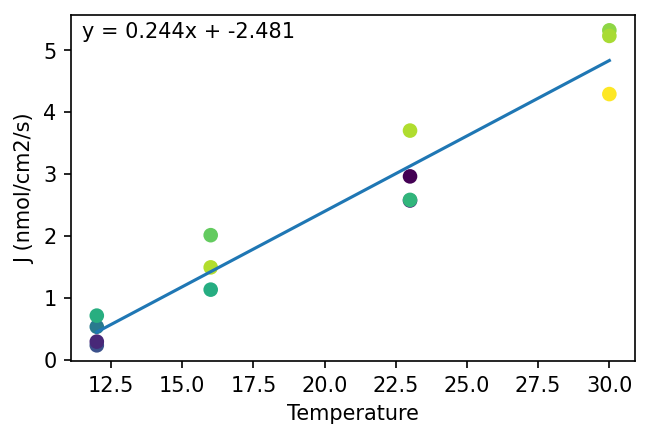

In [173]:
# Explore relationship between J and temperature
plt.scatter(temperature, J_local_flux_nmol_cm2_s, c=foram_diameter_um)
p = np.polyfit(temperature, J_local_flux_nmol_cm2_s, 1)
plt.plot(temperature, np.polyval(p, temperature))
plt.text(0.02, 0.98, f'y = {p[0]:.3f}x + {p[1]:.3f}', transform=plt.gca().transAxes, verticalalignment='top')
plt.xlabel('Temperature')
plt.ylabel('J (nmol/cm2/s)')

Text(0.98, 0.98, 'y = -0.44x + 17.04')

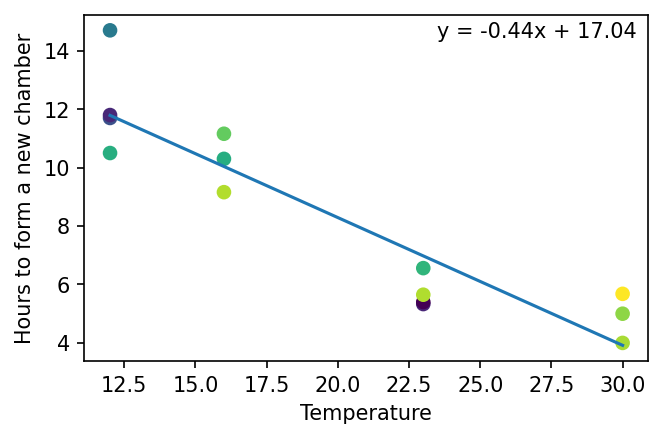

In [174]:
# Explore relationship between time and temperature
plt.scatter(temperature, pumping_time_hrs, c=foram_diameter_um)
p = np.polyfit(temperature, pumping_time_hrs, 1)
plt.plot(temperature, np.polyval(p, temperature))
plt.xlabel('Temperature')
plt.ylabel('Hours to form a new chamber')

plt.text(0.98, 0.98, f'y = {p[0]:.2f}x + {p[1]:.2f}', transform=plt.gca().transAxes, ha='right', va='top')

### What is precipitation rate?

Two ways to calculate precipitation rate:

1. Assume proton pumping is H/0.5Ca, which means precipitation rate is 0.5J in a closed system.
2. Divide total calcite precipitation by duration of calcification.

In [175]:
precip_rate_nmol_cm2_s = 0.5 * J_local_flux_nmol_cm2_s

req_precip_rate_nmol_cm2_s = 1e9 * new_calcite_mol_cm2 / pumping_time_s

Text(0, 0.5, '0.5 J (nmol/cm2/s)')

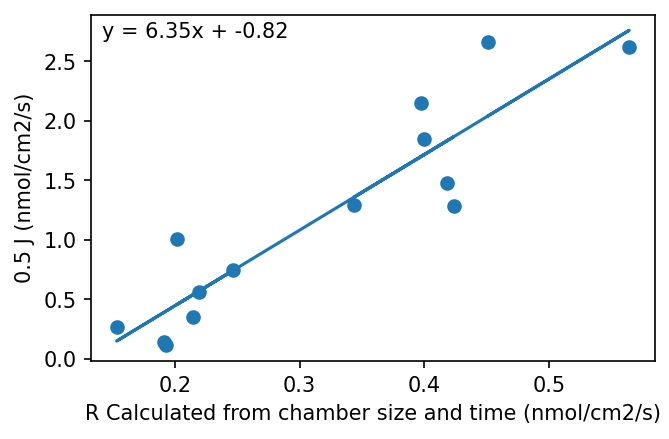

In [176]:
plt.scatter(req_precip_rate_nmol_cm2_s, precip_rate_nmol_cm2_s)
p = np.polyfit(req_precip_rate_nmol_cm2_s, precip_rate_nmol_cm2_s, 1)
plt.plot(req_precip_rate_nmol_cm2_s, np.polyval(p, req_precip_rate_nmol_cm2_s))
plt.text(0.02,0.98, f'y = {p[0]:.2f}x + {p[1]:.2f}', transform=plt.gca().transAxes, verticalalignment='top', horizontalalignment='left')

plt.xlabel('R Calculated from chamber size and time (nmol/cm2/s)')
plt.ylabel('0.5 J (nmol/cm2/s)')

If all proton pumping has a H/0.5Ca stoichiometry, around 6x more Ca is pumped than required for calcification.

## Application of Transport Model

For information on the transport model, see:
 - `transport_model/README.md` for a description of the model equations.
 - `transport_model/model.py` for their implementation.

In the following section, we will run a version of the model for each individual foraminifera in our dataset, each of which has unique chamber diameter, proton pumping rate, temperature, solution pH, and duration of calcification episode. We use the model to predict the Mg/Ca test composition of each foraminfifera, and compare this to the observed Mg/Ca test composition.

In the following, we explore six model scenarios:
1. Constant $K^G$, no $K^J$ - *can Ca pumping alone explain the observed Mg/Ca?*
2. T-Sensitive $K^G$, no $K^J$ - *if the Mg distribution coefficient is temperature sensitive, can this explain Mg/Ca?*
3. T-sensitive $K^G$, constant $K^J = 0.003$ - *can the Mg/Ca be explained by the Ca transporter being slightly 'leaky' to Ca?*
4. T- and rate-sensitive $K^G$, zero $K^J$ - *could the observed pattern be explained by the sensitivity of Mg distribution to mineral precipitation rate?*
5. Constant K^G, constant K^J = 0.003 - *can pumping alone explain the trends we see, or is some inorganic temperature sensitivity required?*
6. Is flushing time important? - *What happens to the model if we change the seawater flushing time?*


In [177]:
# Import transport model
from transport_model import model, plot, utils

In [178]:
# initialise 'flushing time' global parameter
flushing_timescale_min = 40
F_M = 1 / (flushing_timescale_min * 60)  # s-1

f_DIC = 5  # internal DIC elevation factor (DIC_internal = f_DIC * DIC_seawater)

# This implies that the calcifying fluid is flushed by fresch seawater every 40 minutes. 
# This is an initial starting point from which to explore the model, and is refined later.

### Scenario 1: Constant $K^G$, no $K^J$

 - $K^G$ is the trace element distribution coefficient for calcite between the fluid and the solid, and is set to 0.004.
 - $K^J$ is the trace element partitioning coefficient of the hypothesised trans-membrance Ca transporter, and is set to 0 (i.e. the pumps only transport Ca).

For more details, see `transport_model/README.md`.

In [179]:
models = {}

for i, sub in tqdm(dat.iterrows(), total=dat.shape[0]):
    models[i] = model.constant_DIC(sub.chamber_diameter_um, J=sub.J_nmol_cm2_s * 1e-9, temperature=sub.temperature, pHtot=sub.pHtot, hrs_to_run=sub.hrs_to_calcify + 1, F_M=F_M, f_Ca=sub.f_Ca, f_DIC=f_DIC)

  0%|          | 0/14 [00:00<?, ?it/s]

Text(0.5, 0, 'Time (hrs)')

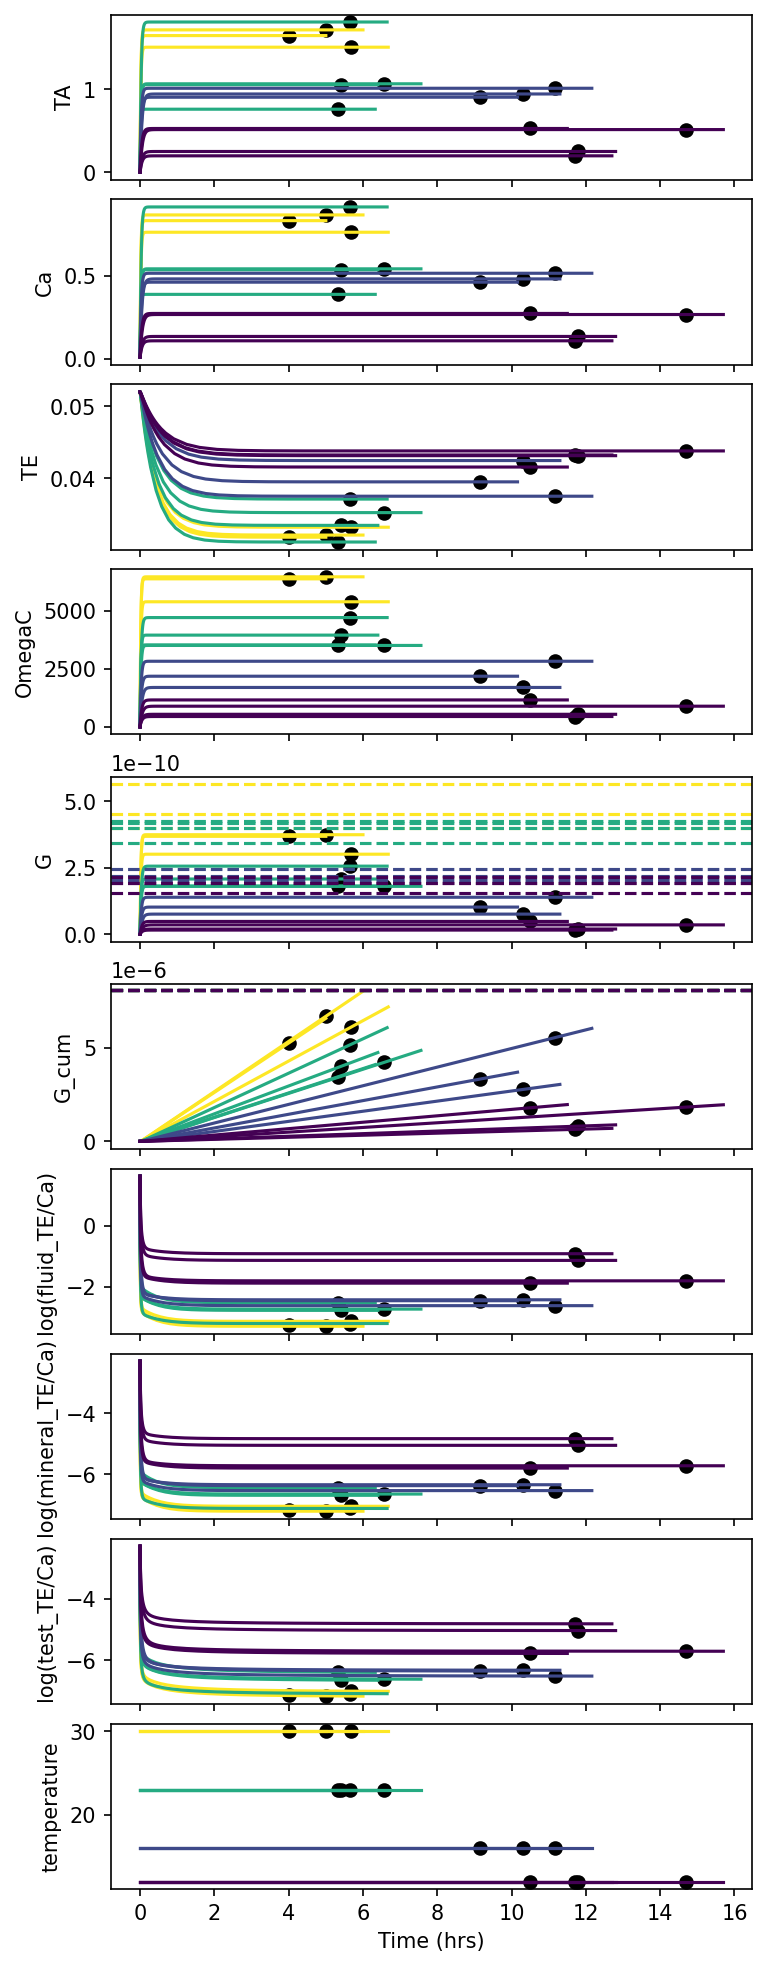

In [180]:
# Show the evolution of the model over time.
cmap = plt.cm.viridis
norm = colors.Normalize(vmin=dat['temperature'].min(), vmax=dat['temperature'].max())

first = True
for i, m in models.items():
    if first:
        axs = None
        first = False
    fig, axs = plot.time_resolved(m, hrs_to_calcify=dat.loc[i, 'hrs_to_calcify'], new_calcite_mol_cm2=dat.loc[i, 'new_calcite_mol_cm2'], axs=axs, label=i, color=cmap(norm(dat.loc[i, 'temperature'])))

for i, row in dat.iterrows():
    axs[4].axhline(row.meas_calc_rate_nmol_cm2_s * 1e-9, color=cmap(norm(row.temperature)), linestyle='--')
    axs[5].axhline(row.new_calcite_mol_cm2, color=cmap(norm(row.temperature)), linestyle='--')

axs[-1].set_xlabel('Time (hrs)')
    

In this plot, each line represents a single foraminifera in our data. The black points along each line represent the observed time that it took that individual to form a new chamber in the experiment. The horizontal dashed lines in the `G` (total calcite precipitation) plot represents the total amount of calcite precipitated by each individual. The point of intersection between the model line and these horizontal lines is not the same, reflecting the discrepancy between observed calcification rates and hypothesised calcium pumping rates.

To consider the impact of Ca pumping on Mg/Ca, we can compare the observed Mg/Ca of each individual to the predicted Mg/Ca from the model. Within the model, we calculate test Mg/Ca in two ways:
1. By calculating the Mg/Ca after the model has run for the observed duration of calcification.
2. By calculating the Mg/Ca after the model has run for the duration of calcification required to precipitate the observed amount of calcite.

In both cases, composition is calculated as a mass-weighted average of the material precipitated throughout the model run (i.e. the initial Mg/Ca that is far from steady state is included in our calculation).

This plot here is shown once here to illustrate the operation of the model. It is not repeated below for each scenario.

In [181]:
# calculate test Mg/Ca for the model run
out = []
out1 = []
for i, m in models.items():
    out.append(utils.get_composition_after_hrs(m, dat.loc[i, 'hrs_to_calcify']))
    out1.append(utils.get_composition_after_calc(m, dat.loc[i, 'new_calcite_mol_cm2']))
    

composition_after_hrs = pd.concat(out, axis=1).T
composition_after_calc = pd.concat(out1, axis=1).T

Text(0.5, 1.0, 'Constant $K^G$, no $K^J$, flushing 40 min')

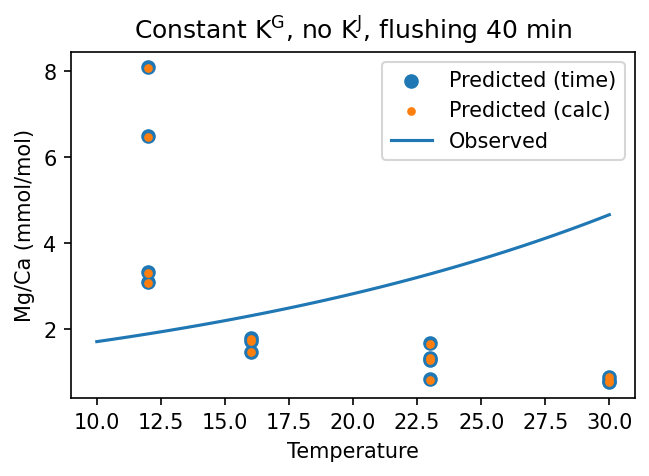

In [182]:
# compare calculated and observed Mg/Ca
plt.scatter(composition_after_hrs.temperature, composition_after_hrs['test_TE/Ca'] * 1e3, label='Predicted (time)')
plt.scatter(composition_after_calc.temperature, composition_after_calc['test_TE/Ca'] * 1e3, label='Predicted (calc)', s=10)
plt.xlabel('Temperature')
plt.ylabel('Mg/Ca (mmol/mol)')

x_temp = np.linspace(10, 30, 50)
plt.plot(x_temp, 1.04 * np.exp(x_temp * 0.05), label='Observed')
plt.legend()

plt.title(f'Constant $K^G$, no $K^J$, flushing {1/F_M/60:.0f} min')

### Scenario 2: T-Sensitive $K^G$, no $K^J$

 - $K^G$ is sensitive to temperature, with Mg/Ca increasing at 3% per degree Celsius. 
 - $K^J$ is set to 0 (i.e. the pumps only transport Ca).

In [183]:
models_2 = {}

for i, sub in tqdm(dat.iterrows(), total=dat.shape[0]):
    K_TE_G = 2.2e-2 * np.exp(0.03 * (sub.temperature - 23.0))
    models_2[i] = model.constant_DIC(sub.chamber_diameter_um, J=sub.J_nmol_cm2_s * 1e-9, temperature=sub.temperature, pHtot=sub.pHtot, K_TE_G=K_TE_G, hrs_to_run=sub.hrs_to_calcify + 1, F_M=F_M, f_DIC=f_DIC)

  0%|          | 0/14 [00:00<?, ?it/s]

In [184]:
# calculate test Mg/Ca for the model run
out = []
out1 = []
for i, m in models_2.items():
    out.append(utils.get_composition_after_hrs(m, dat.loc[i, 'hrs_to_calcify']))
    out1.append(utils.get_composition_after_calc(m, dat.loc[i, 'new_calcite_mol_cm2']))
    
composition_after_hrs_2 = pd.concat(out, axis=1).T
composition_after_calc_2 = pd.concat(out1, axis=1).T

Text(0.5, 1.0, 'T-sensitive $K^G$, no $K^J$, flushing 40 min')

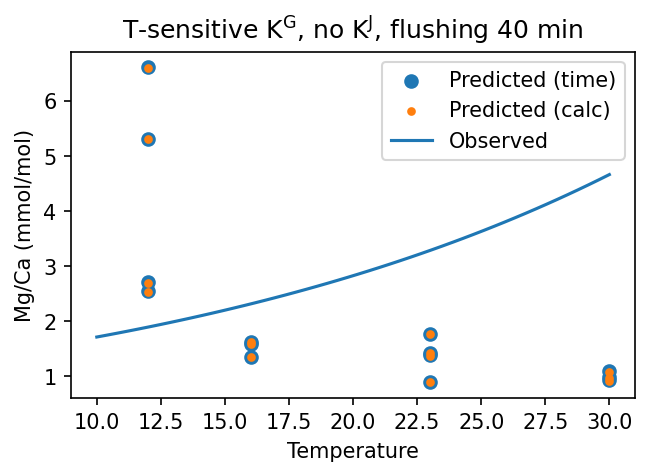

In [185]:
plt.scatter(composition_after_hrs_2.temperature, composition_after_hrs_2['test_TE/Ca'] * 1e3, label='Predicted (time)')
plt.scatter(composition_after_calc_2.temperature, composition_after_calc_2['test_TE/Ca'] * 1e3, s=10, label='Predicted (calc)')
plt.xlabel('Temperature')
plt.ylabel('Mg/Ca (mmol/mol)')

x_temp = np.linspace(10, 30, 50)
plt.plot(x_temp, 1.04 * np.exp(x_temp * 0.05), label='Observed')
plt.legend()

plt.title(f'T-sensitive $K^G$, no $K^J$, flushing {1/F_M/60:.0f} min')

### Scenario 3: T-sensitive $K^G$, fixed $K^J = 0.003$

 - $K^G$ is sensitive to temperature, with Mg/Ca increasing at 3% per degree Celsius. 
 - $K^J$ is set to 0.003 (i.e. Mg leaks through the Ca pump at a rate of 0.003 * Mg/Ca_seawater).

In [186]:
models_3 = {}

for i, sub in tqdm(dat.iterrows(), total=dat.shape[0]):
    K_TE_G = 2.2e-2 * np.exp(0.03 * (sub.temperature - 23.0))
    K_TE_J = 0.003
    models_3[i] = model.constant_DIC(sub.chamber_diameter_um, J=sub.J_nmol_cm2_s * 1e-9, temperature=sub.temperature, pHtot=sub.pHtot, K_TE_G=K_TE_G, K_TE_J=K_TE_J, hrs_to_run=sub.hrs_to_calcify + 1, F_M=F_M, f_DIC=f_DIC)

  0%|          | 0/14 [00:00<?, ?it/s]

In [187]:
out = []
out1 = []
for i, m in models_3.items():
    out.append(utils.get_composition_after_hrs(m, dat.loc[i, 'hrs_to_calcify']))
    out1.append(utils.get_composition_after_calc(m, dat.loc[i, 'new_calcite_mol_cm2']))
    
composition_after_hrs_3 = pd.concat(out, axis=1).T
composition_after_calc_3 = pd.concat(out1, axis=1).T

Text(0.5, 1.0, 'T-sensitive $K^G$, fixed $K^J = 0.003$, flushing 40 min')

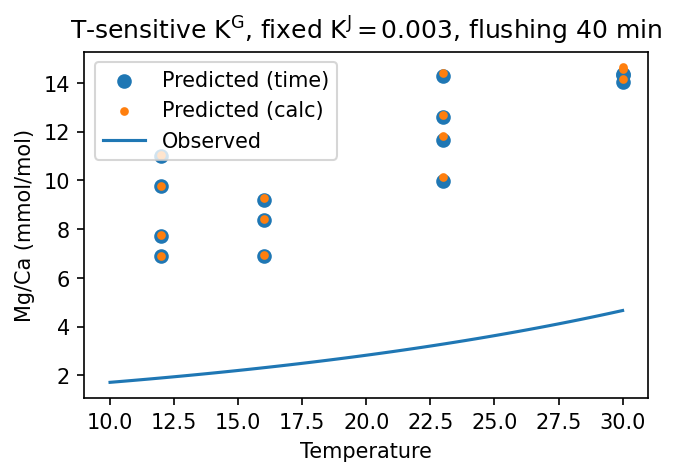

In [188]:
plt.scatter(composition_after_hrs_3.temperature, composition_after_hrs_3['test_TE/Ca'] * 1e3, label='Predicted (time)')
plt.scatter(composition_after_calc_3.temperature, composition_after_calc_3['test_TE/Ca'] * 1e3, s=10, label='Predicted (calc)')
plt.xlabel('Temperature')
plt.ylabel('Mg/Ca (mmol/mol)')

x_temp = np.linspace(10, 30, 50)
plt.plot(x_temp, 1.04 * np.exp(x_temp * 0.05), label='Observed')
plt.legend()

plt.title(f'T-sensitive $K^G$, fixed $K^J = 0.003$, flushing {1/F_M/60:.0f} min')

### Scenario 4: T- and rate-sensitive K^G, zero K^J

 - $K^G$ is sensitive to temperature, with Mg/Ca increasing at 3% per degree Celsius, and linearly increases with precipitation rate. 
 - $K^J$ is set to 0.

In [189]:
# Scenario 4: T- and rate-sensitive K^G, zero K^J
models_4 = {}

for i, sub in tqdm(dat.iterrows(), total=dat.shape[0]):
    K_TE_G = 2.2e-2 * np.exp(0.03 * (sub.temperature - 23.0))
    models_4[i] = model.constant_DIC_rate(sub.chamber_diameter_um, J=sub.J_nmol_cm2_s * 1e-9, temperature=sub.temperature, pHtot=sub.pHtot, K_TE_G=K_TE_G, hrs_to_run=sub.hrs_to_calcify + 1, F_M=F_M, f_DIC=f_DIC)

  0%|          | 0/14 [00:00<?, ?it/s]

In [190]:
out = []
out1 = []
for i, m in models_4.items():
    out.append(utils.get_composition_after_hrs(m, dat.loc[i, 'hrs_to_calcify']))
    out1.append(utils.get_composition_after_calc(m, dat.loc[i, 'new_calcite_mol_cm2']))
    
composition_after_hrs_4 = pd.concat(out, axis=1).T
composition_after_calc_4 = pd.concat(out1, axis=1).T

Text(0.5, 1.0, 'T- and rate-sensitive $K^G$, zero $K^J$, flushing 40 min')

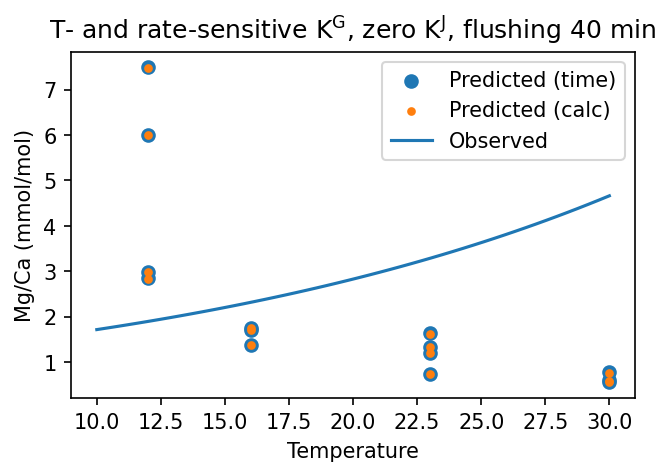

In [191]:
plt.scatter(composition_after_hrs_4.temperature, composition_after_hrs_4['test_TE/Ca'] * 1e3, label='Predicted (time)')
plt.scatter(composition_after_calc_4.temperature, composition_after_calc_4['test_TE/Ca'] * 1e3, s=10, label='Predicted (calc)')
plt.xlabel('Temperature')
plt.ylabel('Mg/Ca (mmol/mol)')

x_temp = np.linspace(10, 30, 50)
plt.plot(x_temp, 1.04 * np.exp(x_temp * 0.05), label='Observed')
plt.legend()

plt.title(f'T- and rate-sensitive $K^G$, zero $K^J$, flushing {1/F_M/60:.0f} min')

### Scenario 5: fixed K^G, fixed K^J

 - $K^G$ is constant and set to 0.004.
 - $K^J$ is constant and set to 0.003.

In [192]:
models_5 = {}

for i, sub in tqdm(dat.iterrows(), total=dat.shape[0]):
    K_TE_J = 0.003
    models_5[i] = model.constant_DIC(sub.chamber_diameter_um, J=sub.J_nmol_cm2_s * 1e-9, temperature=sub.temperature, pHtot=sub.pHtot, K_TE_J=K_TE_J, hrs_to_run=sub.hrs_to_calcify + 1, F_M=F_M, f_DIC=f_DIC)

  0%|          | 0/14 [00:00<?, ?it/s]

In [193]:
out = []
out1 = []
for i, m in models_5.items():
    out.append(utils.get_composition_after_hrs(m, dat.loc[i, 'hrs_to_calcify']))
    out1.append(utils.get_composition_after_calc(m, dat.loc[i, 'new_calcite_mol_cm2']))
    
composition_after_hrs_5 = pd.concat(out, axis=1).T
composition_after_calc_5 = pd.concat(out1, axis=1).T

Text(0.5, 1.0, 'Fixed $K^G$, fixed $K^J = 0.003$, flushing 40 min')

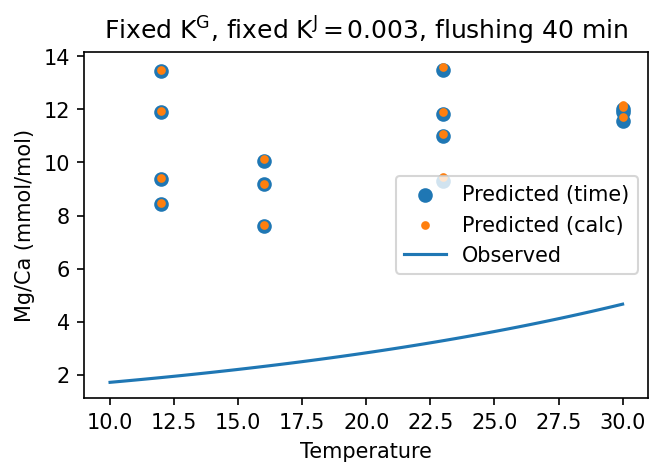

In [194]:
plt.scatter(composition_after_hrs_5.temperature, composition_after_hrs_5['test_TE/Ca'] * 1e3, label='Predicted (time)')
plt.scatter(composition_after_calc_5.temperature, composition_after_calc_5['test_TE/Ca'] * 1e3, s=10, label='Predicted (calc)')
plt.xlabel('Temperature')
plt.ylabel('Mg/Ca (mmol/mol)')

x_temp = np.linspace(10, 30, 50)
plt.plot(x_temp, 1.04 * np.exp(x_temp * 0.05), label='Observed')
plt.legend()

plt.title(f'Fixed $K^G$, fixed $K^J = 0.003$, flushing {1/F_M/60:.0f} min')

### Scenario 6: Is flushing time important?

We run the model with our 'best' configuration (Scenario 3), but double the flushing time to 80 minutes (i.e. slower seawater exchange).

In [195]:
# Scenario 6: Is flushing time important?

models_6 = {}

for i, sub in tqdm(dat.iterrows(), total=dat.shape[0]):
    K_TE_G = 2.2e-2 * np.exp(0.03 * (sub.temperature - 23.0))
    K_TE_J = 0.003
    i_flushing_timescale_min = 80
    i_F_M = 1 / (i_flushing_timescale_min * 60)
    
    models_6[i] = model.constant_DIC(sub.chamber_diameter_um, J=sub.J_nmol_cm2_s * 1e-9, temperature=sub.temperature, pHtot=sub.pHtot, K_TE_G=K_TE_G, K_TE_J=K_TE_J, hrs_to_run=sub.hrs_to_calcify + 1, F_M=i_F_M, f_DIC=f_DIC)

  0%|          | 0/14 [00:00<?, ?it/s]

In [196]:
out = []
out1 = []
for i, m in models_6.items():
    out.append(utils.get_composition_after_hrs(m, dat.loc[i, 'hrs_to_calcify']))
    out1.append(utils.get_composition_after_calc(m, dat.loc[i, 'new_calcite_mol_cm2']))
    
composition_after_hrs_6 = pd.concat(out, axis=1).T
composition_after_calc_6 = pd.concat(out1, axis=1).T

Text(0.5, 1.0, 'T-sensitive $K^G$, fixed $K^J = 0.003$, flushing 80 min')

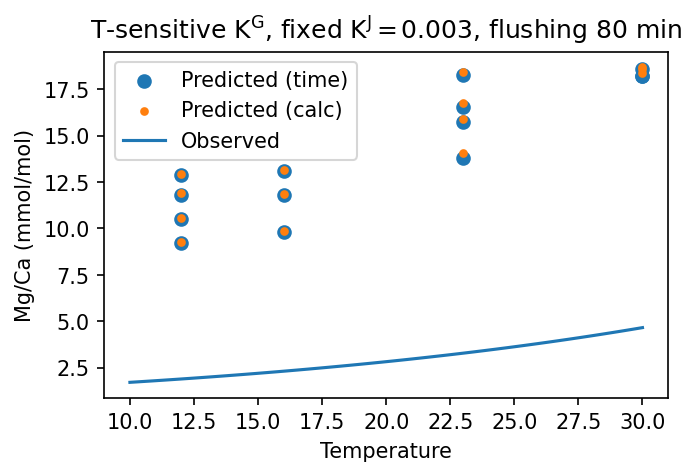

In [197]:
plt.scatter(composition_after_hrs_6.temperature, composition_after_hrs_6['test_TE/Ca'] * 1e3, label='Predicted (time)')
plt.scatter(composition_after_calc_6.temperature, composition_after_calc_6['test_TE/Ca'] * 1e3, s=10, label='Predicted (calc)')
plt.xlabel('Temperature')
plt.ylabel('Mg/Ca (mmol/mol)')

x_temp = np.linspace(10, 30, 50)
plt.plot(x_temp, 1.04 * np.exp(x_temp * 0.05), label='Observed')
plt.legend()

plt.title(f'T-sensitive $K^G$, fixed $K^J = 0.003$, flushing {1/i_F_M/60:.0f} min')

## Model Interpretation

From the scenarios above, we see that three processes are necessary to explain Mg/Ca in our dataset:

1. Temperature sensitivity of the Mg distribution coefficient from fluid to foraminiferal calcite.
2. A small amount of Mg leakage through the Ca transporter.
3. Some degree of seawater flushing the calcifying fluid, on the timescale of ~40 minutes.

In the following, we will consider the temperature sensitivity of the distribution coefficient to be fixed, and explore which combination of flushing time and pump leakage provides the best to the observed Mg/Ca in our dataset.

### Model exploration: iterate across grid of flushing time ($F_M$) & $K^J$ values, calculate G.o.F. for each.

In [198]:
# import some additional libraries for fitting and optimisation
from multiprocessing import Pool  # to speed up the calculations
from sklearn.metrics import r2_score
from scipy.optimize import minimize, curve_fit
import pickle, os

In [199]:
# set grid of parameters to explore
var_F_M = np.linspace(0, 1/(15 * 60), 101)
var_K_TE_J = np.linspace(0, 0.004, 100)

x_F_M, y_K_TE_J = np.meshgrid(var_F_M, var_K_TE_J)

In [200]:
# define helper function for doing the calculations
def _objective(X):
    iF_M, iK_TE_J = X
    
    models = {}

    for r, sub in dat.iterrows():
        K_TE_G = 2.2e-2 * np.exp(0.03 * (sub.temperature - 23.0))
        
        models[r] = model.constant_DIC(sub.chamber_diameter_um, J=sub.J_nmol_cm2_s * 1e-9, temperature=sub.temperature, pHtot=sub.pHtot, K_TE_G=K_TE_G, K_TE_J=iK_TE_J, hrs_to_run=sub.hrs_to_calcify + 1, F_M=iF_M, f_DIC=f_DIC)
    
    return models

In [201]:
# run the grid of scenarios
tmp_file = 'data/tmp_grid_models.pkl'  # temporary file to store the results
rerun = False  # if the set to False, the model is not run - we just load the previous results from the file

if os.path.exists(tmp_file) and not rerun:
    with open(tmp_file, 'rb') as f:
        grid_models = pickle.load(f)
else:
    with Pool() as pool:
        grid_models = list(tqdm(pool.imap(_objective, [(x, y) for x, y in zip(x_F_M.ravel(), y_K_TE_J.ravel())], chunksize=10), total=len(x_F_M.ravel())))

    with open(tmp_file, 'wb') as f:
        pickle.dump(grid_models, f)

In [202]:
# define a function to calculated the temperature sensitivity of Mg/Ca
from scipy.optimize import curve_fit
def T_fn(temp, a, b):
    return a * np.exp(b * temp)

# define a function to calculate goodness of fit statistics for each model

obs = 1.04 * np.exp(dat.temperature * 0.05)  # the observed temperature - Mg/Ca trend

def _calc_stats(models):
    pred_te = []
    for t, m in models.items():
        ij_pred = utils.get_composition_after_hrs(m, dat.loc[t, 'hrs_to_calcify'])
        pred_te.append(ij_pred['test_TE/Ca'] * 1e3)
        
    p, _ = curve_fit(T_fn, dat.Temperature, pred_te, [0.02, 0.003])
    
    pred_te = np.array(pred_te)
    
    return pred_te, np.nansum((obs - pred_te)), np.nansum((obs - pred_te)**2), r2_score(obs, pred_te), p

# apply the stat calculation function to every combination of F_M and K_J in the grid
with Pool() as pool:
    stats = list(tqdm(pool.imap(_calc_stats, grid_models, chunksize=10), total=len(x_F_M.ravel())))

# parse the output into useful arrays
pred = np.array([x[0] for x in stats]).reshape((*x_F_M.shape, dat.shape[0]))
grid_rs = np.array([x[1] for x in stats]).reshape(x_F_M.shape)
grid_rss = np.array([x[2] for x in stats]).reshape(x_F_M.shape)
grid_r2 = np.array([x[3] for x in stats]).reshape(x_F_M.shape)

tfn_p = np.array([x[4][1] for x in stats]).reshape(x_F_M.shape)

mean_pred = pred.mean(axis=-1)

  0%|          | 0/10100 [00:00<?, ?it/s]

With this grid of $K^J$ and $F_M$ values, we will now consider three factors:
1. How does the average test Mg/Ca change?
2. How does the Temperature-Mg/Ca relationship change?
3. Which combination of parameters best predicts observed Mg/Ca data change?

### Result 1: How does the average test Mg/Ca change?

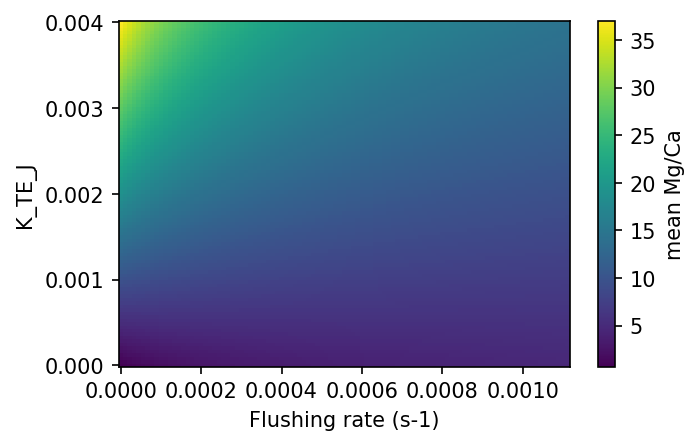

In [203]:
ma = plt.pcolormesh(x_F_M, y_K_TE_J, mean_pred)
plt.xlabel('Flushing rate (s-1)')
plt.ylabel('K_TE_J')

plt.colorbar(ma, label='mean Mg/Ca')

From this, we can see that Mg/Ca increases dramatically at low flushing rates (high flushing times) and high $K^J$ values. This is due to Rayleigh Fractionation, which an emergent property of the model: at low flushing rates, the calcifying fluid is essentially closed from seawater. As a result, if Mg leaks through a Ca transporter, the Mg/Ca of the fluid will increase with time as the Ca is removed from the calcifying fluid and the Mg is left behind.

### Result 2: How does the Temperature-Mg/Ca relationship change?

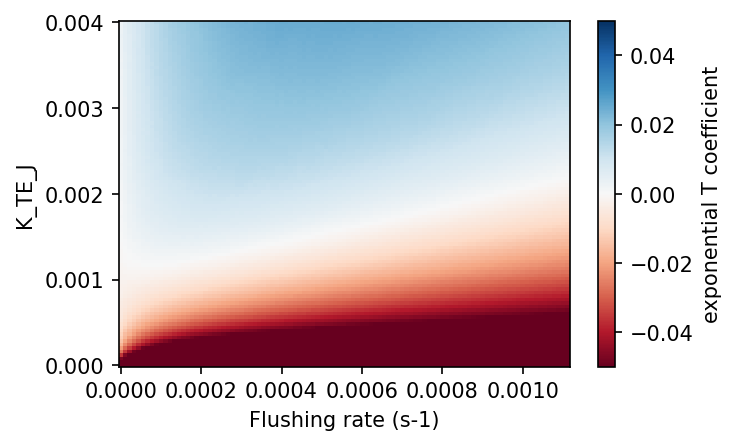

In [204]:
ma = plt.pcolormesh(x_F_M, y_K_TE_J, tfn_p, vmin=-0.05, vmax=0.05, cmap=plt.cm.RdBu)
plt.xlabel('Flushing rate (s-1)')
plt.ylabel('K_TE_J')

plt.colorbar(ma, label='exponential T coefficient')

From this, we see that the positive temperature-Mg/Ca relationship only arises in a configuration with relatively low flushing rates and high Ca pump leakage. If flushing gets too high and leakage gets too low, then the temperature-Mg/Ca relationship is reversed. This happens because in the end member case, a perfect non-leaky Ca pump will elevate [Ca] in seawater, reducing the Mg/Ca ratio. Thus, if a non-leaky Ca pump increases its rate at higher temperatures, the Mg/Ca ratio will decrease with temperature. 

### Result 3: Which combination of parameters best predicts observed Mg/Ca data change?

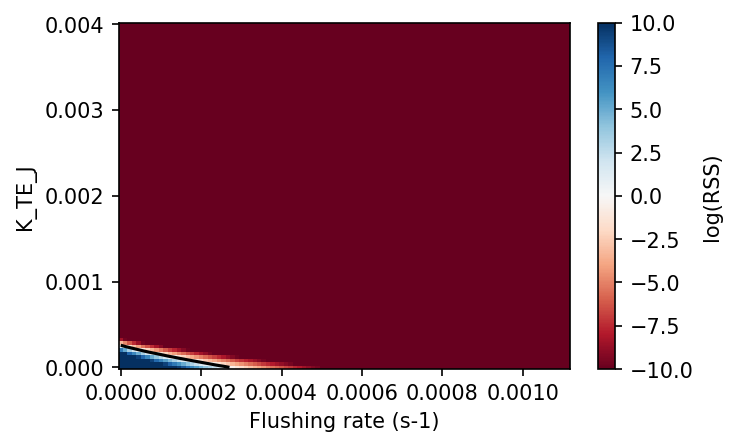

In [205]:
ma = plt.pcolormesh(x_F_M, y_K_TE_J, grid_rs, vmin=-10, vmax=10, cmap=plt.cm.RdBu)
plt.contour(x_F_M, y_K_TE_J, grid_rs, [0], colors=['k'])
plt.xlabel('Flushing rate (s-1)')
plt.ylabel('K_TE_J')

plt.colorbar(ma, label='log(RSS)')

From this, we can see that there are a number of parameters that are able to predict observed Mg/Ca with a reasonable degree of accuracy.

To further explore this, we can use a non-linear optimisation algorithm to find the best combination of parameters that minimises the difference between observed and predicted Mg/Ca.

In [206]:
def _calc_stats(models):
    pred_te = []
    for t, m in models.items():
        ij_pred = utils.get_composition_after_hrs(m, dat.loc[t, 'hrs_to_calcify'])
        pred_te.append(ij_pred['test_TE/Ca'] * 1e3)
        
    p, _ = curve_fit(T_fn, dat.Temperature, pred_te, [0.02, 0.003])
    
    pred_te = np.array(pred_te)
    
    return pred_te, np.nansum((obs - pred_te)), np.nansum((obs - pred_te)**2), r2_score(obs, pred_te), p

In [208]:
# define an objective function for the minimisation function
def objective_fn(X):
    F_M, K_TE_J = X
    
    pred_te = []
    for r, sub in dat.iterrows():
        K_TE_G = 2.2e-2 * np.exp(0.03 * (sub.temperature - 23.0))
        
        m = model.constant_DIC(sub.chamber_diameter_um, J=sub.J_nmol_cm2_s * 1e-9, temperature=sub.temperature, pHtot=sub.pHtot, K_TE_G=K_TE_G, K_TE_J=K_TE_J, hrs_to_run=sub.hrs_to_calcify + 1, F_M=F_M)
        
        i_pred = utils.get_composition_after_hrs(m, sub['hrs_to_calcify'])
        pred_te.append(i_pred['test_TE/Ca'] * 1e3)
    
    rss = np.log(np.nansum((obs - pred_te)**2))
    print(rss)  # so we can monitor progress of the opimisation
    
    return rss

fit = minimize(objective_fn, (1 / (100 * 60), 0.0001), bounds=[(0, 1/(10 * 60)), (0, 0.004)], method='Powell', tol=1e-12)

4.545789760239012
4.533506771820125
4.507519865479554
4.495711621989877
4.489997694781447
4.487633881315416
4.487561610105421
4.487813889249726
4.486334328022756
4.486262140767293
4.486362635737206
4.485917767435328
4.487065292909327
4.486052716901049
4.485877958952359
4.485825714995171
4.485745087869774
4.485727738434113
4.485724291708897
4.48708790842234
4.487096586495742
4.485722924385591
4.485722080596772
4.487097856667286
4.485722402809372
4.485721880851139
4.485721758212549
4.4857216818620795
4.485721634255096
4.485721606325966
4.4857215883686035
4.4870978838168725
4.4857215952990925
4.485721584033133
4.4857215814753975
4.487097887766868
4.485721582281708
4.487097889290704
4.0216952763327045
3.680654488202999
3.4634125308999533
3.3348122600254273
3.2584413305599074
3.21358173370747
3.1869095248064636
3.170766770309977
3.160134259072908
3.154133143333931
3.1504499998596005
3.148183671771193
3.1467868499843727
3.1459250439516673
3.145392984598682
3.1450643705429435
3.14486135870654

  0%|          | 0/14 [00:00<?, ?it/s]

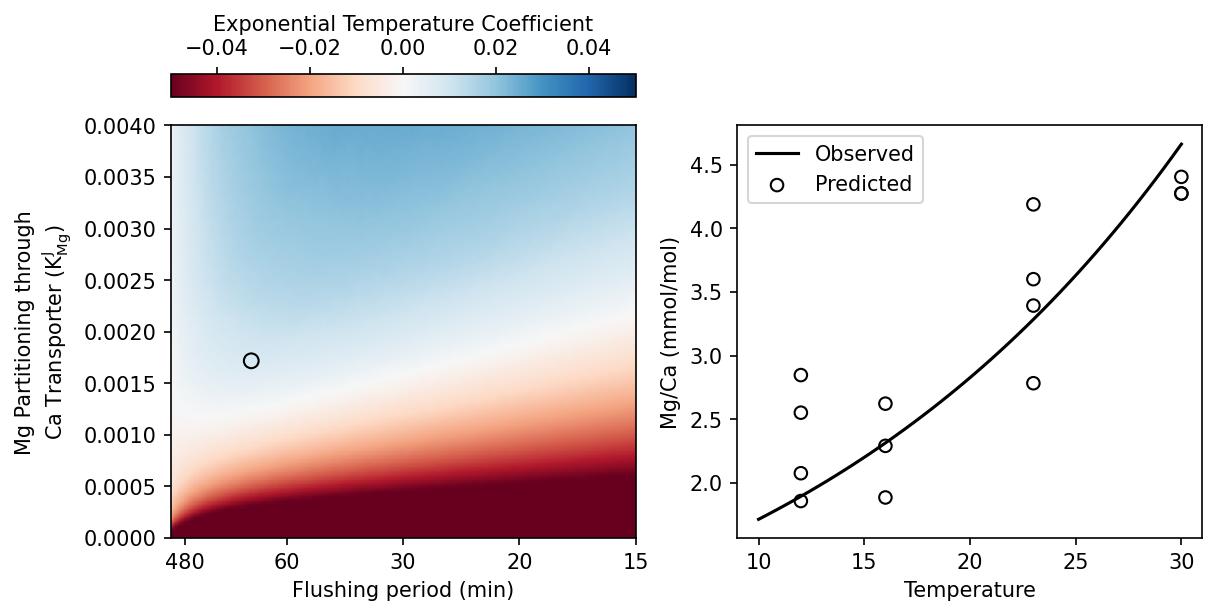

In [209]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

ax0, ax1 = axs

ma = ax0.pcolormesh(x_F_M, y_K_TE_J, tfn_p, vmin=-0.05, vmax=0.05, cmap=plt.cm.RdBu, shading='gouraud')
ax0.set_xlabel('Flushing period (min)')
ax0.set_ylabel('Mg Partitioning through\nCa Transporter ($K^J_{Mg}$)')

ticks_min = np.array([10, 15, 20, 30, 60, 480])
ax0.set_xticks(1 / (ticks_min * 60))
ax0.set_xticklabels(ticks_min)

fig.colorbar(ma, ax=ax0, location='top', label='Exponential Temperature Coefficient')

ax0.scatter(*fit.x, edgecolor='k', lw=1, s=50, facecolor='none')



xt = np.linspace(10, 30, 50)
ypred = 1.04 * np.exp(xt * 0.05) 

models_T = {}
pred_te = []
for i, sub in tqdm(dat.iterrows(), total=dat.shape[0]):
    K_TE_G = 2.2e-2 * np.exp(0.03 * (sub.temperature - 23.0))
    F_M, K_TE_J = fit.x
    
    m = model.constant_DIC(sub.chamber_diameter_um, J=sub.J_nmol_cm2_s * 1e-9, temperature=sub.temperature, pHtot=sub.pHtot, K_TE_G=K_TE_G, K_TE_J=K_TE_J, hrs_to_run=sub.hrs_to_calcify + 1, F_M=F_M)
    
    i_pred = utils.get_composition_after_hrs(m, sub['hrs_to_calcify'])
    pred_te.append(i_pred['test_TE/Ca'] * 1e3)
    

ax1.plot(xt, ypred, label='Observed', color='k')
ax1.scatter(dat.temperature, pred_te, label='Predicted', facecolor='none', edgecolor='k')

ax1.set_xlabel('Temperature')
ax1.set_ylabel('Mg/Ca (mmol/mol)')
ax1.legend()

fig.savefig('figures/model_fit.pdf')

We can also make a similar plot showing the residual sum of squares for each combination of parameters:

  0%|          | 0/14 [00:00<?, ?it/s]

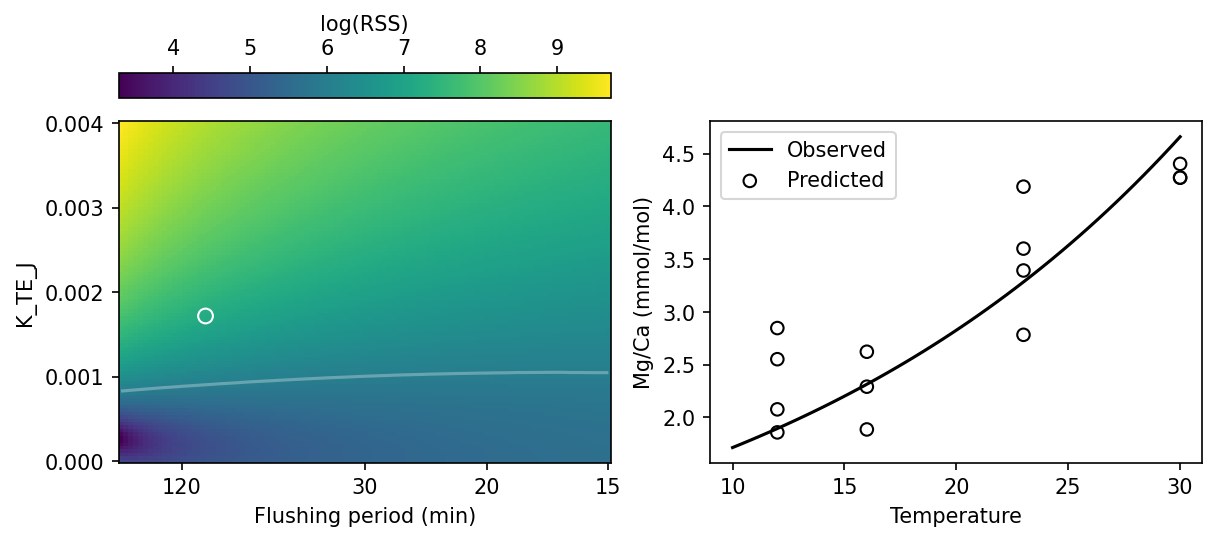

In [210]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)

ax0, ax1 = axs

ma = ax0.pcolormesh(x_F_M, y_K_TE_J, np.log(grid_rss))
ax0.contour(x_F_M, y_K_TE_J, np.log(grid_rss), [1.5,3,6], colors=['w'], alpha=0.3)
# ax0.contour(x_F_M, y_K_TE_J, grid_rs, [0], colors=[(1,1,1,0.3)])
ax0.set_xlabel('Flushing period (min)')
ax0.set_ylabel('K_TE_J')

ticks_min = np.array([10, 15, 20, 30, 120])
ax0.set_xticks(1 / (ticks_min * 60))
ax0.set_xticklabels(ticks_min)

fig.colorbar(ma, ax=ax0, location='top', label='log(RSS)')

ax0.scatter(*fit.x, edgecolor='w', lw=1, s=50, facecolor='none')



xt = np.linspace(10, 30, 50)
ypred = 1.04 * np.exp(xt * 0.05) 

models_T = {}
pred_te = []
for i, sub in tqdm(dat.iterrows(), total=dat.shape[0]):
    K_TE_G = 2.2e-2 * np.exp(0.03 * (sub.temperature - 23.0))
    F_M, K_TE_J = fit.x
    
    m = model.constant_DIC(sub.chamber_diameter_um, J=sub.J_nmol_cm2_s * 1e-9, temperature=sub.temperature, pHtot=sub.pHtot, K_TE_G=K_TE_G, K_TE_J=K_TE_J, hrs_to_run=sub.hrs_to_calcify + 1, F_M=F_M)
    
    i_pred = utils.get_composition_after_hrs(m, sub['hrs_to_calcify'])
    pred_te.append(i_pred['test_TE/Ca'] * 1e3)
    

ax1.plot(xt, ypred, label='Observed', color='k')
ax1.scatter(dat.temperature, pred_te, label='Predicted', facecolor='none', edgecolor='k')

ax1.set_xlabel('Temperature')
ax1.set_ylabel('Mg/Ca (mmol/mol)')
ax1.legend()